# Notebook 03 — Pré-Processamento
## Projeto: Mineração de Dados em Saúde · PNS 2019
### Artrite e Reumatismo em Idosos Brasileiros

**Pesquisador:** Pedro Dias Soares  
**Orientador:** Prof. Dr. Luis Enrique Zárate — PUC Minas  
**Periódico-alvo:** Journal of Health Informatics (JHI/SBIS)

---

## Objetivo deste Notebook

Realizar o **pré-processamento completo** do dataset bivariado (Artrite Pura vs. Saudáveis),
preparando-o para os algoritmos de Aprendizado de Máquina do Notebook 04.

## Etapas

| # | Etapa | Descrição |
|---|-------|-----------|
| 1 | **Carregamento** | Bases SQLite com filtros V0015 e M001 |
| 2 | **Tipos** | Conversão numérica/categórica |
| **2.5** | **⭐ Skip Patterns** | **Resolução de roteamento condicional do questionário PNS** |
| 3 | **Auditoria missing** | Heatmap; decisão inclusão/exclusão |
| 4 | **Outliers** | IQR × 3.0 por classe; substituição por NaN |
| 5 | **Imputação** | Média/classe (num.) · Moda/classe (cat.) — só missing real |
| 6 | **Fusão** | IMC, Escore Inflamatório, Escore Saudável, Razão |
| 7 | **Categorização** | Faixas etárias, IMC-OMS, atividade física, escore |
| 8 | **Encoding** | Label Enc. (ordinais) + OHE (nominais) |
| 9 | **Export** | Dataset final + relatório de rastreabilidade |

---

## Histórico de versões

| # | Descrição |
|---|-----------|
| **v1** | Pipeline inicial |
| **v2** | Correções BUG-01/02, INC-01/02, SUG-01/02 |
| **v3** | ⭐ Etapa 2.5: resolução de skip patterns do questionário PNS 2019 |


## Etapa 1 — Carregamento das Bases


In [1]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 1 — Imports e Configuração do Ambiente
# ══════════════════════════════════════════════════════════════════════

import sqlite3, os, math, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

PASTA_DB       = '../data/database/'
DIR_RESULTADOS = '../data/results/preprocessing/'
DIR_FIGURAS    = DIR_RESULTADOS + 'figuras/'
DIR_TABELAS    = DIR_RESULTADOS + 'tabelas/'
for pasta in [DIR_RESULTADOS, DIR_FIGURAS, DIR_TABELAS]:
    os.makedirs(pasta, exist_ok=True)

RANDOM_STATE    = 42
ALPHA           = 0.05
# INC-01: limiar alinhado em 75% em todo o projeto (código + plano + JSON)
LIMITE_MISSING  = 0.75
# INC-02: renomeado; 3.0×IQR ≈ 3.3 DP para dist. normal (não exatamente 3 DP)
LIMITE_IQR_MULT = 3.0

COR_ARTRITE  = '#C0392B'
COR_SAUDAVEL = '#27AE60'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

def salvar_fig(nome):
    caminho = DIR_FIGURAS + nome
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'  ✅ Figura → {caminho}')

def salvar_tab(df, nome):
    caminho = DIR_TABELAS + nome
    df.to_csv(caminho, encoding='utf-8-sig')
    print(f'  ✅ Tabela → {caminho}')

def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print('✅ Ambiente configurado.')
print(f'   LIMITE_MISSING  : {LIMITE_MISSING*100:.0f}%')
print(f'   LIMITE_IQR_MULT : {LIMITE_IQR_MULT}×IQR (~{LIMITE_IQR_MULT/2.7*3:.1f} DP equivalente)')


✅ Ambiente configurado.
   LIMITE_MISSING  : 75%
   LIMITE_IQR_MULT : 3.0×IQR (~3.3 DP equivalente)


In [2]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 2 — Definição das Variáveis do Estudo
# ══════════════════════════════════════════════════════════════════════
#
# NOTA SOBRE PESO E ALTURA:
#   P00103/P00403 = valores informados pelo respondente (auto-referidos)
#   P00104/P00404 = valores aferidos pelo entrevistador (medida direta)
#   Usamos os aferidos (P00104/P00404) como primeira opção, pois são
#   mais precisos. Variáveis auto-referidas ficam como fallback no NB04.

VARS_CONTINUAS = [
    'P00104',   # Peso aferido (kg)
    'P00404',   # Altura aferida (cm)
    'VDF004',   # Renda per capita (quintil 1–7)
]

VARS_DISCRETAS = [
    'C008',     # Idade (anos)
    'P035',     # Exercício físico (dias/semana) — CONDICIONAL: só se P034=1
    'P04501',   # Televisão (horas/dia)
    'P00901',   # Verduras/legumes (dias/semana)
    'P015',     # Peixe (dias/semana)
    'P018',     # Frutas (dias/semana)
    'P01101',   # Carne vermelha (dias/semana)
    'P02501',   # Doces/ultraprocessados (dias/semana)
    'P02002',   # Refrigerante (dias/semana)
    'P02001',   # Suco de caixinha/refresco em pó (dias/semana)
    'P023',     # Leite (dias/semana)
    'P01601',   # Suco de fruta natural (dias/semana)
    'P02602',   # Lanche rápido substituindo almoço (dias/semana)
    'J012',     # Consultas médicas nos últimos 12 meses — CONDICIONAL: só se J01101=1
    'P02801',   # Dias/semana com consumo de álcool — CONDICIONAL: só se P027=3
    'P029',     # Doses de álcool por ocasião — CONDICIONAL: só se P027≠1
]

VARS_NOMINAIS = [
    'C006',     # Sexo
    'P034',     # Praticou exercício físico? (PAI de P035)
    'I00101',   # Tem plano de saúde?
    'J01101',   # Última consulta médica (PAI de J012)
    'J01002',   # Local usual de atendimento
    'G059',     # Usa aparelho de auxílio para locomoção? (PAI de G060/G062)
    'G060',     # Usa cadeira de rodas? — CONDICIONAL: só se G059=1
    'G062',     # Usa bengala/muleta/andador? — CONDICIONAL: só se G059=1
    'Q092',     # Diagnóstico de depressão
    'Q11006',   # Diagnóstico de outra doença mental
    'Q00201',   # Diagnóstico de hipertensão
    'Q03001',   # Diagnóstico de diabetes
    'Q060',     # Diagnóstico de colesterol alto
    'Q06306',   # Diagnóstico de doença cardíaca
    'Q068',     # Diagnóstico de AVC
    'Q084',     # Problema crônico de coluna
    'Q074',     # Diagnóstico de asma
    'Q120',     # Diagnóstico de câncer
    'Q124',     # Diagnóstico de insuficiência renal crônica
    'Q11604',   # Diagnóstico de DPOC
    'P00603',   # Consumo de feijão no dia anterior
    'P00620',   # Consumo de embutidos no dia anterior
    'P02601',   # Percepção do consumo de sal
    'P027',     # Frequência de consumo de álcool (PAI de P028/P029/P03201)
    'P03201',   # Binge drinking nos últimos 30 dias — CONDICIONAL: só se P027≠1
]

VARS_ORDINAIS = [
    'VDD004A',  # Escolaridade (1=Sem instrução … 5=Superior completo)
    'N001',     # Autoavaliação de saúde (1=Muito boa … 5=Muito ruim)
    'N010',     # Problemas de sono
    'N011',     # Cansaço/falta de energia
    'G070',     # Dificuldade de caminhar/subir degraus
    'Q115',     # Limitação por doença mental
    'Q109',     # Limitação pela depressão
]

TODAS_VARS = (VARS_CONTINUAS + VARS_DISCRETAS +
              VARS_NOMINAIS  + VARS_ORDINAIS  + ['Q079'])

print(f'✅ Variáveis definidas:')
print(f'   Contínuas     : {len(VARS_CONTINUAS)}')
print(f'   Discretas     : {len(VARS_DISCRETAS)}  (inclui 3 com skip pattern)')
print(f'   Nominais      : {len(VARS_NOMINAIS)}  (inclui 3 com skip pattern)')
print(f'   Ordinais      : {len(VARS_ORDINAIS)}')
print(f'   TOTAL features: {len(VARS_CONTINUAS)+len(VARS_DISCRETAS)+len(VARS_NOMINAIS)+len(VARS_ORDINAIS)}')


✅ Variáveis definidas:
   Contínuas     : 3
   Discretas     : 16  (inclui 3 com skip pattern)
   Nominais      : 25  (inclui 3 com skip pattern)
   Ordinais      : 7
   TOTAL features: 51


In [3]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 3 — Carregamento das Bases SQLite
# ══════════════════════════════════════════════════════════════════════

print('Executando a partir de:', os.getcwd())

colunas_sql = list(dict.fromkeys(['V0015', 'M001'] + TODAS_VARS))
SQL_NB03 = f"SELECT {', '.join(colunas_sql)} FROM pns_idosos"

ARQUIVOS = {
    'idosos_artrite_puro.db': 'Com Artrite',
    'idosos_saudaveis.db'   : 'Saudável',
}

dfs, log_carga = [], []
for arquivo, classe in ARQUIVOS.items():
    caminho = PASTA_DB + arquivo
    if not os.path.exists(caminho):
        print(f'  ⚠️  {arquivo} não encontrado — ignorado.')
        continue
    conn   = sqlite3.connect(caminho)
    df_tmp = pd.read_sql_query(SQL_NB03, conn)
    conn.close()
    n_bruto = len(df_tmp)

    # Filtro V0015
    if 'V0015' in df_tmp.columns:
        df_tmp['V0015'] = df_tmp['V0015'].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})
        if df_tmp['V0015'].notna().sum() > 0:
            mask = (pd.to_numeric(df_tmp['V0015'], errors='coerce') == 1) | \
                   df_tmp['V0015'].astype(str).str.strip().str.lower().isin(['1','01','realizada','sim'])
            df_tmp = df_tmp[mask]

    # Filtro M001
    if 'M001' in df_tmp.columns:
        df_tmp['M001'] = df_tmp['M001'].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})
        if df_tmp['M001'].notna().mean() >= 0.10:
            mask = (pd.to_numeric(df_tmp['M001'], errors='coerce') == 1) | \
                   df_tmp['M001'].astype(str).str.strip().str.lower().isin(['1','01','realizada','sim'])
            df_tmp = df_tmp[mask]

    df_tmp['Classe'] = classe
    pct = 100 * len(df_tmp) / n_bruto if n_bruto > 0 else 0
    print(f'  📦 {classe:12s}: {n_bruto:,} bruto → {len(df_tmp):,} válidos ({pct:.1f}%)')
    dfs.append(df_tmp)
    log_carga.append({'Base': arquivo, 'Classe': classe, 'n_bruto': n_bruto, 'n_valido': len(df_tmp)})

if not dfs:
    raise FileNotFoundError('Nenhuma base encontrada. Verifique PASTA_DB.')

df_raw = pd.concat(dfs, ignore_index=True)
df_raw.drop(columns=['V0015', 'M001'], errors='ignore', inplace=True)

n_dup = df_raw.duplicated().sum()
print(f'  {"⚠️  " + str(n_dup) + " registros duplicados" if n_dup > 0 else "✅ Nenhum registro duplicado."}')
print(f'\n📊 Dataset bruto: {len(df_raw):,} registros × {df_raw.shape[1]} colunas')
print(f'   Com Artrite : {(df_raw["Classe"]=="Com Artrite").sum():,}')
print(f'   Saudáveis   : {(df_raw["Classe"]=="Saudável").sum():,}')


Executando a partir de: D:\Faculdade\Semestre 3\Mineração de Dados\Python\Projeto\Projeto_PNS\.claude\worktrees\eloquent-mendeleev-79fe4e\notebooks
  📦 Com Artrite : 494 bruto → 494 válidos (100.0%)


  📦 Saudável    : 4,332 bruto → 4,332 válidos (100.0%)
  ✅ Nenhum registro duplicado.

📊 Dataset bruto: 4,826 registros × 53 colunas
   Com Artrite : 494
   Saudáveis   : 4,332


---
## Etapa 2 — Conversão de Tipos


In [4]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 4 — Conversão de Tipos + Padronização Inicial
# ══════════════════════════════════════════════════════════════════════

VARS_NUMERICAS = VARS_CONTINUAS + VARS_DISCRETAS

for col in VARS_NUMERICAS:
    if col not in df_raw.columns:
        continue
    if col == 'P04501':
        direto    = pd.to_numeric(df_raw[col], errors='coerce')
        via_regex = df_raw[col].astype(str).str.extract(r'(\d+\.?\d*)')[0]
        df_raw[col] = direto.fillna(pd.to_numeric(via_regex, errors='coerce'))
    elif col in ['P00104', 'P00404']:
        df_raw[col] = pd.to_numeric(
            df_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    else:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

for col in VARS_ORDINAIS:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

for col in VARS_NOMINAIS:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).str.strip()
        df_raw[col] = df_raw[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan})

# P027 numérico para skip logic na Célula 5
if 'P027' in df_raw.columns:
    df_raw['P027_num'] = pd.to_numeric(df_raw['P027'], errors='coerce')

# J01101 numérico para skip logic
if 'J01101' in df_raw.columns:
    df_raw['J01101_num'] = pd.to_numeric(df_raw['J01101'], errors='coerce')

# G059 numérico para skip logic
if 'G059' in df_raw.columns:
    df_raw['G059_num'] = pd.to_numeric(df_raw['G059'], errors='coerce')

# P034 numérico para skip logic
if 'P034' in df_raw.columns:
    df_raw['P034_num'] = pd.to_numeric(df_raw['P034'], errors='coerce')

print('✅ Conversão de tipos concluída.')


✅ Conversão de tipos concluída.


---
## Etapa 2.5 — ⭐ Resolução de Roteamento Condicional (Skip Patterns)

### Por que esta etapa é necessária?

O questionário da PNS 2019 usa **roteamento condicional**: dependendo da resposta de uma
pergunta (pai), o entrevistado é direcionado para perguntas diferentes, pulando as intermediárias.
Quando uma pergunta é **pulada**, o campo fica **NaN** — mas esse NaN **não é dado ausente**:
é um valor **estruturalmente determinado** pela resposta da pergunta pai.

Tratar esses NaNs estruturais como missing aleatório e imputá-los pela média/moda **introduz
viés metodológico**. O correto é preenchê-los com o valor implicado pelo roteamento.

### Mapa de skip patterns identificados neste estudo

| Variável filho | Pergunta pai | Condição de skip | Valor implícito | Fundamento no questionário |
|---|---|---|---|---|
| **P035** (dias exercício/sem.) | P034 | P034 = 2 (Não praticou) | **0** | *'P34=Não → passe P42'* — quem não pratica tem 0 dias |
| **P02801** (dias bebe/sem.) | P027 | P027 = 1 (Nunca bebe) | **0** | *'P27=1 → passe P34'* — abstinente tem 0 dias |
| **P029** (doses por ocasião) | P027 | P027 = 1 (Nunca bebe) | **0** | *'P27=1 → passe P34'* — abstinente tem 0 doses |
| **P03201** (binge drinking) | P027 | P027 = 1 (Nunca bebe) | **'2' (Não)** | *'P27=1 → passe P34'* — abstinente nunca faz binge |
| **J012** (consultas/12m) | J01101 | J01101 ≠ 1 (não consultou no último ano) | **0** | *'J11a=1 → siga J12; senão passe J13a'* |
| **G060** (cadeira de rodas) | G059 | G059 = 2 (não usa aux. locomoção) | **'2' (Não)** | *'G59=2 → passe G71'* |
| **G062** (bengala/muleta) | G059 | G059 = 2 (não usa aux. locomoção) | **'2' (Não)** | *'G59=2 → passe G71'* |

> **Nota sobre diagnósticos médicos** (Q00201, Q03001, Q060, etc.): Também possuem perguntas
> pai (exames de sangue Q1a, Q29a, Q59a), mas essas variáveis pai **não estão disponíveis** neste
> recorte da PNS. Além disso, no desenho *artrite pura vs. saudáveis*, todas as comorbidades
> são estruturalmente '2 (Não)' por critério de inclusão — conforme tratado na Etapa 8.


In [5]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 5 — Resolução de Skip Patterns
# ══════════════════════════════════════════════════════════════════════
#
# Princípio: NaN estrutural ≠ NaN aleatório.
# Quando a pergunta foi pulada por roteamento condicional, o NaN tem
# um valor determinístico fixado pelo questionário. Preencher ANTES
# da auditoria de missing para que a auditoria reflita apenas o
# missing real (recusa, não-sabe, falha de coleta).

df_raw2 = df_raw.copy()
log_skip = []

def aplicar_skip(df, col_filho, col_pai_num, mascara_skip, valor_implicito,
                 descricao_pai, descricao_filho, valor_pai_texto):
    # Preenche NaN estruturais em col_filho onde col_pai satisfaz mascara_skip.
    # Retorna (df modificado, n_registros_preenchidos).
    if col_pai_num not in df.columns or col_filho not in df.columns:
        return df, 0
    # Aplica apenas em registros onde: (1) pai tem a resposta de skip E
    #                                   (2) filho está NaN
    mask = mascara_skip & df[col_filho].isna()
    n = int(mask.sum())
    if n > 0:
        df.loc[mask, col_filho] = valor_implicito
    return df, n

# ─────────────────────────────────────────────────────────────────────
# SKIP 1: P035 ← P034
# Questão P34: "Praticou algum tipo de exercício físico ou esporte?"
#   1=Sim (siga P35) | 2=Não (passe P38/P42)
# Quem NÃO praticou (P034=2) → P035 = 0 dias/semana
# ─────────────────────────────────────────────────────────────────────
df_raw2, n = aplicar_skip(
    df_raw2,
    col_filho    = 'P035',
    col_pai_num  = 'P034_num',
    mascara_skip = df_raw2.get('P034_num', pd.Series(dtype=float)) == 2,
    valor_implicito = 0.0,
    descricao_pai   = 'P034 = 2 (Não praticou exercício)',
    descricao_filho = 'P035 (dias exercício/semana)',
    valor_pai_texto = 'P034=2'
)
log_skip.append({'Variável': 'P035', 'Pai': 'P034', 'Condição': 'P034=2 (Não)',
                 'Valor_Implicito': '0 dias/sem.', 'n_preenchidos': n})
print(f'  SKIP-1  P035 ← P034=2  →  {n:,} registros preenchidos com 0')

# ─────────────────────────────────────────────────────────────────────
# SKIP 2: P02801 ← P027
# Questão P27: "Com que frequência consome bebida alcoólica?"
#   1=Nunca (passe P34) | 2=<1x/mês (passe P29) | 3=≥1x/mês (siga P28a)
# P28a (P02801) é APENAS perguntado se P027=3 → dias/semana que bebe
# Quem NUNCA bebe (P027=1) → P02801 = 0 dias/semana
# Quem bebe <1x/mês (P027=2) → P028a é pulado mas a resposta seria 0 também
#   pois 0 = "nunca ou menos de 1x por semana" é a categoria da própria questão
# ─────────────────────────────────────────────────────────────────────
mask_nao_bebe = df_raw2.get('P027_num', pd.Series(dtype=float)).isin([1, 2])
df_raw2, n = aplicar_skip(
    df_raw2,
    col_filho    = 'P02801',
    col_pai_num  = 'P027_num',
    mascara_skip = mask_nao_bebe,
    valor_implicito = 0.0,
    descricao_pai   = 'P027 = 1 (nunca) ou 2 (<1x/mês)',
    descricao_filho = 'P02801 (dias/sem. bebida)',
    valor_pai_texto = 'P027∈{1,2}'
)
log_skip.append({'Variável': 'P02801', 'Pai': 'P027', 'Condição': 'P027∈{1,2} (não bebe semanalmente)',
                 'Valor_Implicito': '0 dias/sem.', 'n_preenchidos': n})
print(f'  SKIP-2  P02801 ← P027∈{{1,2}}  →  {n:,} registros preenchidos com 0')

# ─────────────────────────────────────────────────────────────────────
# SKIP 3: P029 ← P027
# Questão P29: "Quantas doses de bebida alcoólica consome por ocasião?"
# É perguntado após P28a (se P027=3) ou diretamente pulado para P33a
# se P027=2. Se P027=1 (nunca bebe) → P29 é completamente pulado.
# Quem NUNCA bebe → P029 = 0 doses
# ─────────────────────────────────────────────────────────────────────
df_raw2, n = aplicar_skip(
    df_raw2,
    col_filho    = 'P029',
    col_pai_num  = 'P027_num',
    mascara_skip = df_raw2.get('P027_num', pd.Series(dtype=float)) == 1,
    valor_implicito = 0.0,
    descricao_pai   = 'P027 = 1 (nunca bebe)',
    descricao_filho = 'P029 (doses por ocasião)',
    valor_pai_texto = 'P027=1'
)
log_skip.append({'Variável': 'P029', 'Pai': 'P027', 'Condição': 'P027=1 (nunca bebe)',
                 'Valor_Implicito': '0 doses', 'n_preenchidos': n})
print(f'  SKIP-3  P029 ← P027=1  →  {n:,} registros preenchidos com 0')

# ─────────────────────────────────────────────────────────────────────
# SKIP 4: P03201 ← P027
# Questão P32a: "Nos últimos 30 dias consumiu 5 ou mais doses em uma
#               única ocasião?" (binge drinking)
# Rota: P27=3 → siga P28a → siga P29 → siga P32a
#        P27=2 → passe P29 → siga P32a
#        P27=1 → passe P34 (skip total do bloco álcool)
# Quem NUNCA bebe → P03201 = '2' (Não — nunca fez binge)
# ─────────────────────────────────────────────────────────────────────
df_raw2, n = aplicar_skip(
    df_raw2,
    col_filho    = 'P03201',
    col_pai_num  = 'P027_num',
    mascara_skip = df_raw2.get('P027_num', pd.Series(dtype=float)) == 1,
    valor_implicito = '2',   # '2' = Não (binge drinking)
    descricao_pai   = 'P027 = 1 (nunca bebe)',
    descricao_filho = 'P03201 (binge drinking últimos 30 dias)',
    valor_pai_texto = 'P027=1'
)
log_skip.append({'Variável': 'P03201', 'Pai': 'P027', 'Condição': 'P027=1 (nunca bebe)',
                 'Valor_Implicito': "'2' (Não)", 'n_preenchidos': n})
print(f'  SKIP-4  P03201 ← P027=1  →  {n:,} registros preenchidos com "2" (Não)')

# ─────────────────────────────────────────────────────────────────────
# SKIP 5: J012 ← J01101
# Questão J11a: "Quando consultou médico pela última vez?"
#   1=Até 1 ano (siga J12) | 2=1-2 anos | 3=2-3 anos | 4=>3 anos | 5=Nunca
# J12 (J012): "Quantas vezes consultou médico nos últimos 12 meses?"
# Só é feita se J11a=1. Para todos os outros → J012 = 0 consultas.
#
# ⚠️  IMPACTO CRÍTICO: J012 é uma das features mais discriminativas
# (artríticos consultam mais). Tratar os NaNs de J01101≠1 como missing
# e imputar pela média distorceria completamente o escore.
# ─────────────────────────────────────────────────────────────────────
df_raw2, n = aplicar_skip(
    df_raw2,
    col_filho    = 'J012',
    col_pai_num  = 'J01101_num',
    mascara_skip = ~df_raw2.get('J01101_num', pd.Series(dtype=float)).isin([1]),
    valor_implicito = 0.0,
    descricao_pai   = 'J01101 ≠ 1 (não consultou médico no último ano)',
    descricao_filho = 'J012 (consultas médicas/12m)',
    valor_pai_texto = 'J01101≠1'
)
log_skip.append({'Variável': 'J012', 'Pai': 'J01101', 'Condição': 'J01101≠1 (não consultou no último ano)',
                 'Valor_Implicito': '0 consultas', 'n_preenchidos': n})
print(f'  SKIP-5  J012 ← J01101≠1  →  {n:,} registros preenchidos com 0')

# ─────────────────────────────────────────────────────────────────────
# SKIP 6 e 7: G060/G062 ← G059
# Questão G59: "Usa algum aparelho de auxílio para locomoção?"
#   1=Sim (siga G60 → G62) | 2=Não (passe G71)
# G060 (cadeira de rodas) e G062 (bengala/muleta) são pulados se G059=2.
# Quem não usa aparelho → ambos = '2' (Não)
# Nota: G060 e G062 têm >75% missing e serão excluídos na Etapa 3,
# mas documentamos o skip para rigor metodológico.
# ─────────────────────────────────────────────────────────────────────
for col_g, desc_g in [('G060', 'cadeira de rodas'), ('G062', 'bengala/muleta/andador')]:
    df_raw2, n = aplicar_skip(
        df_raw2,
        col_filho    = col_g,
        col_pai_num  = 'G059_num',
        mascara_skip = df_raw2.get('G059_num', pd.Series(dtype=float)) == 2,
        valor_implicito = '2',
        descricao_pai   = 'G059=2 (não usa aparelho de auxílio)',
        descricao_filho = f'{col_g} ({desc_g})',
        valor_pai_texto = 'G059=2'
    )
    log_skip.append({'Variável': col_g, 'Pai': 'G059', 'Condição': 'G059=2 (não usa aparelho)',
                     'Valor_Implicito': "'2' (Não)", 'n_preenchidos': n})
    skip_num = 6 if col_g == 'G060' else 7
    print(f'  SKIP-{skip_num}  {col_g} ← G059=2  →  {n:,} registros preenchidos com "2" (Não)')

# ─────────────────────────────────────────────────────────────────────
# Limpeza das colunas auxiliares de skip
# ─────────────────────────────────────────────────────────────────────
cols_aux = ['P027_num', 'J01101_num', 'G059_num', 'P034_num']
df_raw2.drop(columns=[c for c in cols_aux if c in df_raw2.columns], inplace=True)

# Atualiza df_raw para uso nas etapas seguintes
df_raw = df_raw2.copy()
del df_raw2

# Log da etapa
tab_skip = pd.DataFrame(log_skip)
salvar_tab(tab_skip, 'etapa2_5_skip_patterns.csv')

total_skip = tab_skip['n_preenchidos'].sum()
print(f'\n  ✅ Skip patterns resolvidos: {total_skip:,} células preenchidas')
print(f'     Distribuição:')
for _, row in tab_skip.iterrows():
    print(f'     {row["Variável"]:10s} → {row["n_preenchidos"]:,} ({row["Condição"]})')
print(f'\n  ⚠️  IMPACTO METODOLÓGICO:')
print(f'     Esses {total_skip:,} valores NÃO eram missing aleatório —')
print(f'     eram NaN estrutural determinado pelo roteamento do questionário.')
print(f'     A auditoria de missing (Etapa 3) agora reflete apenas missing real.')


  SKIP-1  P035 ← P034=2  →  0 registros preenchidos com 0
  SKIP-2  P02801 ← P027∈{1,2}  →  0 registros preenchidos com 0
  SKIP-3  P029 ← P027=1  →  0 registros preenchidos com 0
  SKIP-4  P03201 ← P027=1  →  0 registros preenchidos com "2" (Não)
  SKIP-5  J012 ← J01101≠1  →  1,344 registros preenchidos com 0
  SKIP-6  G060 ← G059=2  →  0 registros preenchidos com "2" (Não)
  SKIP-7  G062 ← G059=2  →  0 registros preenchidos com "2" (Não)
  ✅ Tabela → ../data/results/preprocessing/tabelas/etapa2_5_skip_patterns.csv

  ✅ Skip patterns resolvidos: 1,344 células preenchidas
     Distribuição:
     P035       → 0 (P034=2 (Não))
     P02801     → 0 (P027∈{1,2} (não bebe semanalmente))
     P029       → 0 (P027=1 (nunca bebe))
     P03201     → 0 (P027=1 (nunca bebe))
     J012       → 1,344 (J01101≠1 (não consultou no último ano))
     G060       → 0 (G059=2 (não usa aparelho))
     G062       → 0 (G059=2 (não usa aparelho))

  ⚠️  IMPACTO METODOLÓGICO:
     Esses 1,344 valores NÃO eram mi

---
## Etapa 3 — Auditoria de Dados Ausentes (Missing)

> **Após** a resolução dos skip patterns, o missing aqui é **real** (recusa, não-sabe,
> falha de coleta) — não mais confundido com ausências estruturais do roteamento.



  AUDITORIA DE MISSING REAL (após skip patterns)
Variável  % Missing  n Missing         Decisão
  VDF004      100.0       4826  EXCLUIR (>75%)
  P04501      100.0       4826  EXCLUIR (>75%)
    Q115      100.0       4826  EXCLUIR (>75%)
    N001      100.0       4826  EXCLUIR (>75%)
    N011      100.0       4826  EXCLUIR (>75%)
    G070      100.0       4826  EXCLUIR (>75%)
    Q109      100.0       4826  EXCLUIR (>75%)
 VDD004A      100.0       4826  EXCLUIR (>75%)
    N010      100.0       4826  EXCLUIR (>75%)
    G060       96.9       4676  EXCLUIR (>75%)
    G062       96.9       4676  EXCLUIR (>75%)
  P02602       90.6       4372  EXCLUIR (>75%)
  P02801       82.0       3956  EXCLUIR (>75%)
  P02001       73.8       3564 IMPUTAR (1–75%)
    P035       72.0       3475 IMPUTAR (1–75%)
  P03201       70.8       3419 IMPUTAR (1–75%)
    P029       70.8       3419 IMPUTAR (1–75%)
  P02002       69.0       3332 IMPUTAR (1–75%)
  P02501       56.6       2733 IMPUTAR (1–75%)
    P015  

  ✅ Figura → ../data/results/preprocessing/figuras/etapa3_heatmap_missing.png


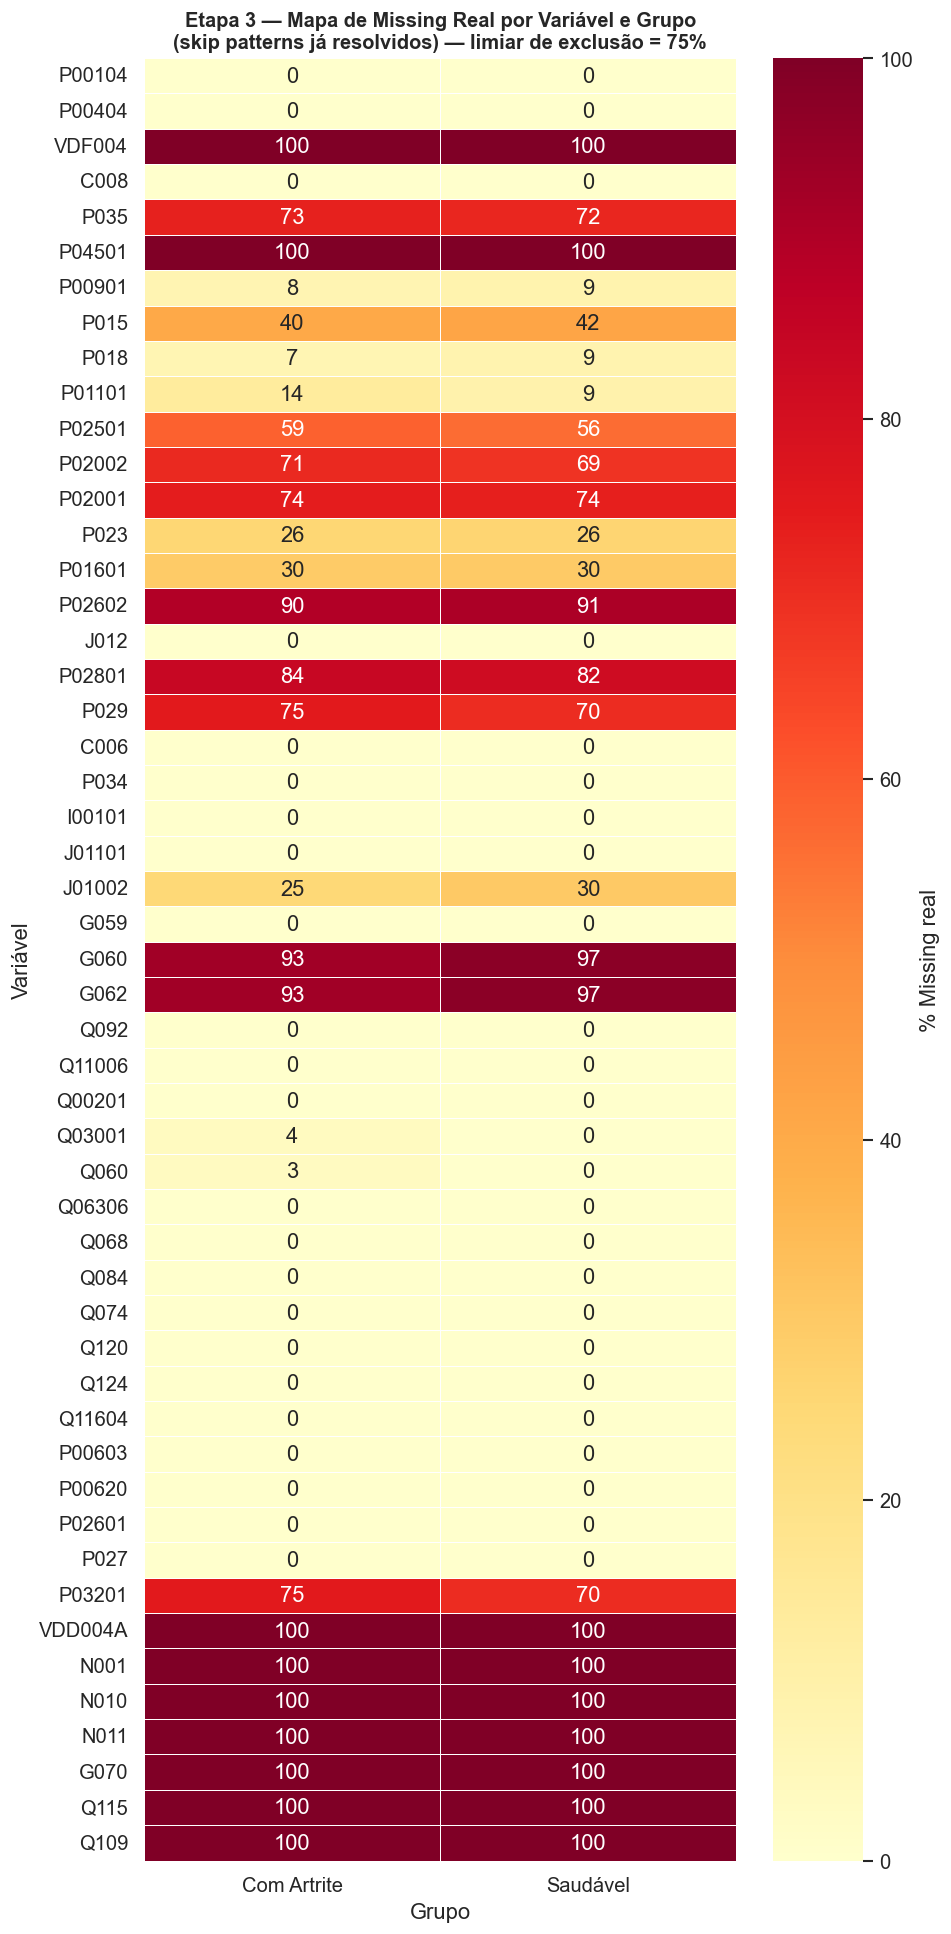

In [6]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 6 — Auditoria de Dados Ausentes (Missing Real)
# ══════════════════════════════════════════════════════════════════════
#
# NOTA MCAR/MAR/MNAR (SUG-02):
# O heatmap por grupo permite identificar o mecanismo de ausência.
# Para variáveis com padrão similar entre grupos → assume-se MAR.
# Para padrão assimétrico entre grupos → possível MNAR (declarar no artigo).
# Após os skip patterns, o missing restante é genuíno.

colunas_features = [c for c in df_raw.columns if c not in ['Classe', 'Q079']]
taxa_missing = df_raw[colunas_features].isna().mean() * 100
taxa_missing = taxa_missing.sort_values(ascending=False)

tab_missing = pd.DataFrame({
    'Variável'  : taxa_missing.index,
    '% Missing' : taxa_missing.values.round(1),
    'n Missing' : df_raw[taxa_missing.index].isna().sum().values,
    'Decisão'   : ['EXCLUIR (>75%)' if p > LIMITE_MISSING * 100 else
                   'IMPUTAR (1–75%)' if p > 0 else
                   'COMPLETA (0%)'
                   for p in taxa_missing.values]
})
print('=' * 70)
print('  AUDITORIA DE MISSING REAL (após skip patterns)')
print('=' * 70)
print(tab_missing.to_string(index=False))
salvar_tab(tab_missing, 'etapa3_auditoria_missing.csv')

vars_excluir = taxa_missing[taxa_missing > LIMITE_MISSING * 100].index.tolist()
print(f'\n  Variáveis a EXCLUIR (>{int(LIMITE_MISSING*100)}% missing real): {vars_excluir}')

# Heatmap por grupo
miss_por_classe = (
    df_raw.groupby('Classe')[colunas_features]
    .apply(lambda g: g.isna().mean() * 100)
    .T
)

fig, ax = plt.subplots(figsize=(8, max(8, len(colunas_features) * 0.32)))
sns.heatmap(miss_por_classe, annot=True, fmt='.0f',
            cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.4, linecolor='white',
            ax=ax, cbar_kws={'label': '% Missing real'})
ax.set_title(
    'Etapa 3 — Mapa de Missing Real por Variável e Grupo\n'
    '(skip patterns já resolvidos) — limiar de exclusão = 75%',
    fontsize=12, fontweight='bold')
ax.set_xlabel('Grupo'); ax.set_ylabel('Variável')
plt.tight_layout()
salvar_fig('etapa3_heatmap_missing.png')
plt.show()


In [7]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 7 — Aplicação do Critério de Exclusão (>75% missing real)
# ══════════════════════════════════════════════════════════════════════

n_vars_antes = df_raw.shape[1] - 2

df_step1 = df_raw.drop(columns=vars_excluir, errors='ignore').copy()

VARS_CONTINUAS_OK = [v for v in VARS_CONTINUAS if v in df_step1.columns]
VARS_DISCRETAS_OK = [v for v in VARS_DISCRETAS  if v in df_step1.columns]
VARS_NOMINAIS_OK  = [v for v in VARS_NOMINAIS   if v in df_step1.columns]
VARS_ORDINAIS_OK  = [v for v in VARS_ORDINAIS   if v in df_step1.columns]
VARS_NUM_OK       = VARS_CONTINUAS_OK + VARS_DISCRETAS_OK

n_vars_depois = df_step1.shape[1] - 2
print('=' * 70)
print('  RESULTADO DA EXCLUSÃO')
print('=' * 70)
print(f'  Variáveis antes    : {n_vars_antes}')
print(f'  Excluídas (>75%)   : {len(vars_excluir)} → {vars_excluir}')
print(f'  Mantidas           : {n_vars_depois}')
print(f'  Shape após etapa 3 : {df_step1.shape[0]:,} × {df_step1.shape[1]}')


  RESULTADO DA EXCLUSÃO
  Variáveis antes    : 51
  Excluídas (>75%)   : 13 → ['VDF004', 'P04501', 'Q115', 'N001', 'N011', 'G070', 'Q109', 'VDD004A', 'N010', 'G060', 'G062', 'P02602', 'P02801']
  Mantidas           : 38
  Shape após etapa 3 : 4,826 × 40


---
## Etapa 4 — Remoção de Outliers (IQR · 3.0×)


In [8]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 8 — Remoção de Outliers pelo Método IQR (por classe)
# ══════════════════════════════════════════════════════════════════════

df_step2 = df_step1.copy()
log_outliers = []

for col in VARS_NUM_OK:
    if col not in df_step2.columns:
        continue
    mask_outlier = pd.Series(False, index=df_step2.index)
    for classe in df_step2['Classe'].unique():
        idx = df_step2['Classe'] == classe
        serie = df_step2.loc[idx, col].dropna()
        if len(serie) < 10:
            continue
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lim_inf = q1 - LIMITE_IQR_MULT * iqr
        lim_sup = q3 + LIMITE_IQR_MULT * iqr
        mask_outlier |= idx & ((df_step2[col] < lim_inf) | (df_step2[col] > lim_sup))

    n_out = int(mask_outlier.sum())
    if n_out > 0:
        df_step2.loc[mask_outlier, col] = np.nan
        n_validos = int(df_step2[col].notna().sum() + n_out)  # pré-substituição
        pct_val = 100 * n_out / n_validos if n_validos else 0
        print(f'  {col:12s}: {n_out:4d} outliers → NaN ({pct_val:.2f}% dos válidos)')
    log_outliers.append({'Variável': col, 'n_outliers': n_out,
                         '% outliers': round(100*n_out/max(1, int(df_step2[col].notna().sum() + n_out)), 2),
                         'Ação': 'Substituído por NaN' if n_out > 0 else 'Sem outliers'})

tab_outliers = pd.DataFrame(log_outliers)
salvar_tab(tab_outliers, 'etapa4_log_outliers.csv')
print(f'\n  Total outliers substituídos: {tab_outliers["n_outliers"].sum():,}')


  P00104      :    2 outliers → NaN (0.04% dos válidos)
  C008        :    2 outliers → NaN (0.04% dos válidos)
  P02002      :    7 outliers → NaN (0.47% dos válidos)


  J012        :   24 outliers → NaN (0.50% dos válidos)


  P029        :   15 outliers → NaN (1.07% dos válidos)
  ✅ Tabela → ../data/results/preprocessing/tabelas/etapa4_log_outliers.csv

  Total outliers substituídos: 50


  ✅ Figura → ../data/results/preprocessing/figuras/etapa4_boxplots_outliers.png


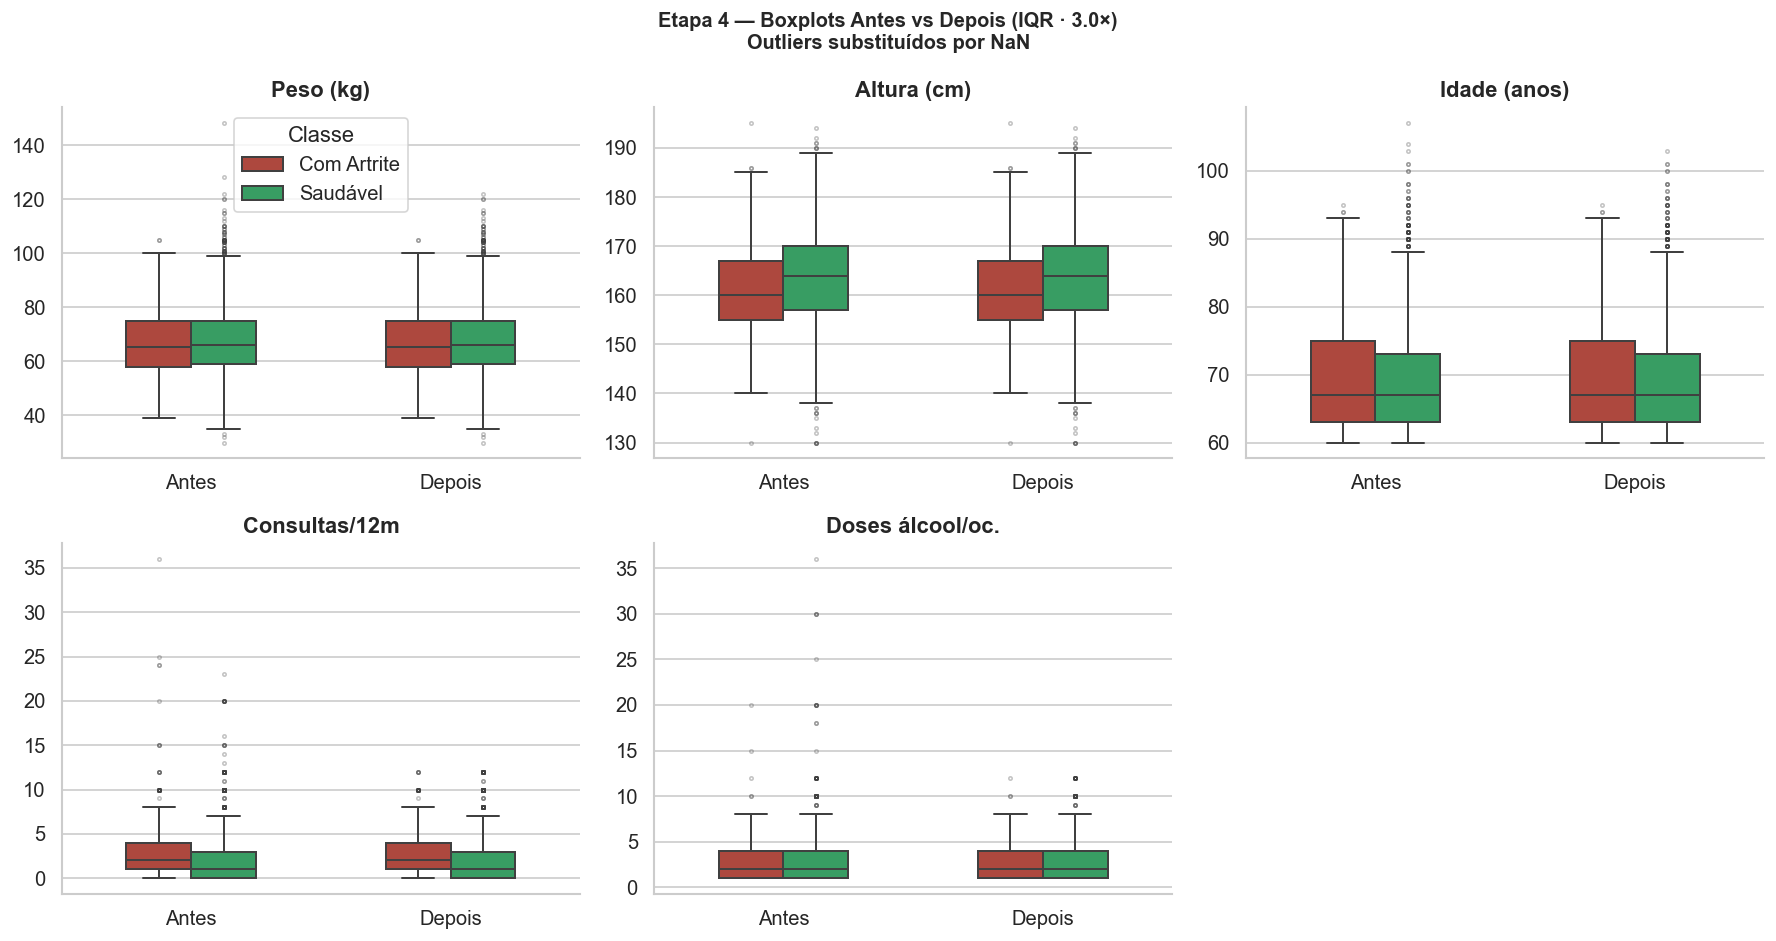

In [9]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 9 — Boxplots Antes vs Depois dos Outliers
# ══════════════════════════════════════════════════════════════════════

VARS_VIZ_OUT = [v for v in ['P00104','P00404','C008','J012','P02801','P029']
                if v in df_step1.columns and v in df_step2.columns]
ROTULOS_VIZ = {'P00104':'Peso (kg)','P00404':'Altura (cm)','C008':'Idade (anos)',
               'J012':'Consultas/12m','P02801':'Dias álcool/sem.','P029':'Doses álcool/oc.'}

n_vars = len(VARS_VIZ_OUT)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(VARS_VIZ_OUT):
    ax = axes[i]
    df_a = df_step1[['Classe', col]].copy(); df_a['Etapa'] = 'Antes'
    df_d = df_step2[['Classe', col]].copy(); df_d['Etapa'] = 'Depois'
    df_plot = pd.concat([df_a, df_d], ignore_index=True)
    sns.boxplot(data=df_plot, x='Etapa', y=col, hue='Classe', ax=ax,
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                order=['Antes','Depois'], width=0.5, linewidth=1.2,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(ROTULOS_VIZ.get(col, col), fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    if i > 0: ax.get_legend().remove()

if VARS_VIZ_OUT:
    for j in range(len(VARS_VIZ_OUT), len(axes)): axes[j].set_visible(False)
fig.suptitle(f'Etapa 4 — Boxplots Antes vs Depois (IQR · {LIMITE_IQR_MULT}×)\n'
             'Outliers substituídos por NaN', fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig('etapa4_boxplots_outliers.png')
plt.show()


---
## Etapa 5 — Imputação de Dados Ausentes (Missing Real)

> Após os skip patterns (Etapa 2.5), o missing aqui é genuíno.
> Imputamos pela **média/moda da própria classe** para preservar as distribuições por grupo.


In [10]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 10 — Imputação de Missing Real (média/moda por classe)
# ══════════════════════════════════════════════════════════════════════
#
# IMPORTANTE: apenas o missing REAL é imputado aqui.
# Os NaNs estruturais (skip patterns) já foram preenchidos na Etapa 2.5
# com valores determinísticos — NÃO devem ser imputados por média/moda.
#
# Variáveis com >70% de missing real retidas (P02001, P029, P03201):
# Recomendar análise de sensibilidade no NB04 (modelo com/sem elas).

df_step3 = df_step2.copy()
log_imp   = []

# Imputação Numérica (Média por Classe)
for col in VARS_NUM_OK:
    if col not in df_step3.columns:
        continue
    n_antes = df_step3[col].isna().sum()
    if n_antes == 0:
        log_imp.append({'Variável': col, 'Tipo': 'Numérica',
                        'Método': 'Média/classe', 'n_imputados': 0})
        continue
    for classe in df_step3['Classe'].unique():
        m = df_step3['Classe'] == classe
        df_step3.loc[m & df_step3[col].isna(), col] = df_step3.loc[m, col].mean()
    n_imp = int(n_antes - df_step3[col].isna().sum())
    log_imp.append({'Variável': col, 'Tipo': 'Numérica',
                    'Método': 'Média/classe', 'n_imputados': n_imp})
    if n_imp > 0:
        print(f'  NUM {col:12s}: {n_imp:5,} valores imputados (média real/classe)')

# Imputação Qualitativa (Moda por Classe)
for col in VARS_NOMINAIS_OK + VARS_ORDINAIS_OK:
    if col not in df_step3.columns:
        continue
    n_antes = df_step3[col].isna().sum()
    if n_antes == 0:
        log_imp.append({'Variável': col, 'Tipo': 'Qualitativa',
                        'Método': 'Moda/classe', 'n_imputados': 0})
        continue
    for classe in df_step3['Classe'].unique():
        m = df_step3['Classe'] == classe
        serie = df_step3.loc[m, col].dropna()
        if len(serie) == 0: continue
        moda = serie.mode()
        if len(moda) == 0: continue
        df_step3.loc[m & df_step3[col].isna(), col] = moda.iloc[0]
    n_imp = int(n_antes - df_step3[col].isna().sum())
    log_imp.append({'Variável': col, 'Tipo': 'Qualitativa',
                    'Método': 'Moda/classe', 'n_imputados': n_imp})
    if n_imp > 0:
        print(f'  CAT {col:12s}: {n_imp:5,} valores imputados (moda real/classe)')

tab_imp = pd.DataFrame(log_imp)
salvar_tab(tab_imp, 'etapa5_log_imputacao.csv')
nan_restante = df_step3.drop(columns=['Classe','Q079'], errors='ignore').isna().sum().sum()
print(f'\n  Total imputado (missing real): {tab_imp["n_imputados"].sum():,}')
print(f'  NaN residuais                : {nan_restante}')
print(f'  Dataset após etapa 5         : {df_step3.shape}')


  NUM P00104      :     4 valores imputados (média real/classe)
  NUM P00404      :     2 valores imputados (média real/classe)
  NUM C008        :     2 valores imputados (média real/classe)
  NUM P035        : 3,475 valores imputados (média real/classe)
  NUM P00901      :   420 valores imputados (média real/classe)
  NUM P015        : 2,011 valores imputados (média real/classe)
  NUM P018        :   404 valores imputados (média real/classe)
  NUM P01101      :   460 valores imputados (média real/classe)
  NUM P02501      : 2,733 valores imputados (média real/classe)
  NUM P02002      : 3,339 valores imputados (média real/classe)
  NUM P02001      : 3,564 valores imputados (média real/classe)
  NUM P023        : 1,266 valores imputados (média real/classe)
  NUM P01601      : 1,436 valores imputados (média real/classe)
  NUM J012        :    24 valores imputados (média real/classe)
  NUM P029        : 3,434 valores imputados (média real/classe)
  CAT J01002      : 1,427 valores imputa

---
## Etapa 6 — Fusão de Atributos


In [11]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 11 — Fusão de Atributos (Feature Engineering)
# ══════════════════════════════════════════════════════════════════════

df_step4 = df_step3.copy()

# IMC
if 'P00104' in df_step4.columns and 'P00404' in df_step4.columns:
    peso   = pd.to_numeric(df_step4['P00104'], errors='coerce')
    altura = pd.to_numeric(df_step4['P00404'], errors='coerce') / 100
    df_step4['IMC'] = peso / (altura ** 2)
    df_step4.loc[(df_step4['IMC'] < 10) | (df_step4['IMC'] > 70), 'IMC'] = np.nan
    print(f'  ✅ IMC | média={df_step4["IMC"].mean():.1f} | NaN={df_step4["IMC"].isna().sum()}')

# Escore Inflamatório
vars_infla = [v for v in ['P01101','P02501','P02002','P02001'] if v in df_step4.columns]
if vars_infla:
    df_step4['Escore_Inflamatorio'] = df_step4[vars_infla].sum(axis=1, min_count=1)
    print(f'  ✅ Escore_Inflamatorio | componentes={vars_infla} | média={df_step4["Escore_Inflamatorio"].mean():.1f}')

# Escore Saudável
vars_saud = [v for v in ['P018','P00901','P015','P023','P01601'] if v in df_step4.columns]
if vars_saud:
    df_step4['Escore_Saudavel'] = df_step4[vars_saud].sum(axis=1, min_count=1)
    print(f'  ✅ Escore_Saudavel | componentes={vars_saud} | média={df_step4["Escore_Saudavel"].mean():.1f}')

# Razão
if 'Escore_Inflamatorio' in df_step4.columns and 'Escore_Saudavel' in df_step4.columns:
    df_step4['Razao_Inf_Saud'] = df_step4['Escore_Inflamatorio'] / (df_step4['Escore_Saudavel'] + 1)
    print(f'  ✅ Razao_Inf_Saud | média={df_step4["Razao_Inf_Saud"].mean():.2f}')
    print(f'     💡 Considerar log(Razao_Inf_Saud) antes do treino ML para reduzir assimetria.')

print(f'\n  Dataset após etapa 6: {df_step4.shape[0]:,} × {df_step4.shape[1]}')


  ✅ IMC | média=25.3 | NaN=0
  ✅ Escore_Inflamatorio | componentes=['P01101', 'P02501', 'P02002', 'P02001'] | média=12.5
  ✅ Escore_Saudavel | componentes=['P018', 'P00901', 'P015', 'P023', 'P01601'] | média=21.3
  ✅ Razao_Inf_Saud | média=0.59
     💡 Considerar log(Razao_Inf_Saud) antes do treino ML para reduzir assimetria.

  Dataset após etapa 6: 4,826 × 44


---
## Etapa 7 — Categorização Ordinal de Risco


In [12]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 12 — Categorização Ordinal de Risco
# ══════════════════════════════════════════════════════════════════════

df_step5 = df_step4.copy()

# 1. Faixa Etária (OMS para idosos)
if 'C008' in df_step5.columns:
    df_step5['FxEtaria_cat'] = pd.cut(df_step5['C008'], bins=[59,69,79,120],
                                       labels=[0,1,2], include_lowest=True).astype(float)
    print('  ✅ FxEtaria_cat: 0=60–69 | 1=70–79 | 2=80+')

# 2. IMC — OMS
if 'IMC' in df_step5.columns:
    df_step5['IMC_cat'] = pd.cut(df_step5['IMC'], bins=[0,18.5,25,30,100],
                                  labels=[0,1,2,3], include_lowest=True, right=False).astype(float)
    print('  ✅ IMC_cat: 0=Baixo peso | 1=Normal | 2=Sobrepeso | 3=Obesidade')

# 3. Atividade Física
# NOTA: P035 agora reflete corretamente 0 para quem não pratica (skip pattern resolvido)
# Portanto AtivFisica_cat=0 (Sedentário) captura quem não pratica exercício.
if 'P035' in df_step5.columns:
    df_step5['AtivFisica_cat'] = pd.cut(df_step5['P035'], bins=[-0.1,0,2,4,7],
                                         labels=[0,1,2,3], include_lowest=True).astype(float)
    print('  ✅ AtivFisica_cat: 0=Sedentário | 1=Pouco ativo | 2=Moderado | 3=Ativo')
    pct_sed = 100 * (df_step5['AtivFisica_cat'] == 0).sum() / len(df_step5)
    print(f'     Sedentários (P035=0, inclui P034=Não): {pct_sed:.1f}%')

# 4. Renda — guard para VDF004 excluída na Etapa 3
if 'VDF004' in df_step5.columns:
    df_step5['Renda_cat'] = pd.cut(df_step5['VDF004'], bins=[0,2,4,7],
                                    labels=[0,1,2], include_lowest=True).astype(float)
    print('  ✅ Renda_cat criada.')
else:
    print('  ⚠️  VDF004 ausente — Renda_cat NÃO criada (limitação do estudo).')

# 5. Escore Inflamatório — quartis
if 'Escore_Inflamatorio' in df_step5.columns and df_step5['Escore_Inflamatorio'].notna().sum() > 4:
    try:
        df_step5['EscInfla_cat'] = pd.qcut(df_step5['Escore_Inflamatorio'], q=4,
                                            labels=[0,1,2,3], duplicates='drop').astype(float)
        print('  ✅ EscInfla_cat: 0=Q1 (menor) | 1=Q2 | 2=Q3 | 3=Q4 (maior risco inflamatório)')
    except Exception as e:
        print(f'  ⚠️  EscInfla_cat não criada ({e})')

# 6. Autoavaliação de Saúde — guard para N001 excluída
if 'N001' in df_step5.columns:
    n001_num = pd.to_numeric(df_step5['N001'], errors='coerce')
    df_step5['Saude_cat'] = pd.cut(n001_num, bins=[0,2,3,5], labels=[0,1,2],
                                    include_lowest=True).astype(float)
    print('  ✅ Saude_cat criada.')
else:
    print('  ⚠️  N001 ausente — Saude_cat NÃO criada (limitação do estudo).')

novas_cat = [c for c in df_step5.columns if c.endswith('_cat')]
print(f'\n  Dataset após etapa 7: {df_step5.shape[0]:,} × {df_step5.shape[1]}')
print(f'  Colunas _cat criadas ({len(novas_cat)}): {novas_cat}')


  ✅ FxEtaria_cat: 0=60–69 | 1=70–79 | 2=80+
  ✅ IMC_cat: 0=Baixo peso | 1=Normal | 2=Sobrepeso | 3=Obesidade
  ✅ AtivFisica_cat: 0=Sedentário | 1=Pouco ativo | 2=Moderado | 3=Ativo
     Sedentários (P035=0, inclui P034=Não): 0.0%
  ⚠️  VDF004 ausente — Renda_cat NÃO criada (limitação do estudo).
  ✅ EscInfla_cat: 0=Q1 (menor) | 1=Q2 | 2=Q3 | 3=Q4 (maior risco inflamatório)
  ⚠️  N001 ausente — Saude_cat NÃO criada (limitação do estudo).

  Dataset após etapa 7: 4,826 × 48
  Colunas _cat criadas (4): ['FxEtaria_cat', 'IMC_cat', 'AtivFisica_cat', 'EscInfla_cat']


---
## Etapa 8 — Encoding para o Modelo ML


In [13]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 13 — Encoding de Variáveis Categóricas
# ══════════════════════════════════════════════════════════════════════

df_step6 = df_step5.copy()

# Label Encoding (ordinais)
cols_label = [c for c in VARS_ORDINAIS_OK if c in df_step6.columns]
print('  Label Encoding (ordinais):')
if cols_label:
    for col in cols_label:
        col_num = pd.to_numeric(df_step6[col], errors='coerce')
        col_min = col_num.min()
        if col_min > 0:
            df_step6[col] = (col_num - col_min).astype(float)
            print(f'    {col}: mín={col_min:.0f} → ajustado para 0')
        else:
            df_step6[col] = col_num
            print(f'    {col}: já começa em 0')
else:
    print('    Nenhuma ordinal mantida (todas excluídas por 100% missing).')

# One-Hot Encoding (nominais) — BUG-01: Q092 excluída do OHE E do DataFrame
cols_ohe = [c for c in VARS_NOMINAIS_OK if c in df_step6.columns and c != 'Q092']
print(f'\n  OHE ({len(cols_ohe)} variáveis nominais):')

if cols_ohe:
    dummies = pd.get_dummies(df_step6[cols_ohe], prefix=cols_ohe,
                             drop_first=True, dummy_na=False, dtype=int)
    df_step6.drop(columns=cols_ohe, inplace=True)
    df_step6 = pd.concat([df_step6, dummies], axis=1)
    print(f'    {len(dummies.columns)} colunas binárias criadas.')

    # SUG-01: diagnóstico de variáveis que não geraram colunas
    vars_nao_geradas = [c for c in cols_ohe
                        if not any(col.startswith(c) for col in df_step6.columns)]
    if vars_nao_geradas:
        print(f'\n  ⚠️  OHE não gerou colunas para: {vars_nao_geradas}')
        print(f'     Causa: constantes nesta amostra (declarar como limitação).')

# BUG-01: remoção explícita de Q092
if 'Q092' in df_step6.columns:
    df_step6.drop(columns=['Q092'], inplace=True)
    print('\n  ✅ BUG-01: Q092 removida do DataFrame.')

print(f'\n  Dataset após etapa 8: {df_step6.shape[0]:,} × {df_step6.shape[1]}')


  Label Encoding (ordinais):
    Nenhuma ordinal mantida (todas excluídas por 100% missing).

  OHE (22 variáveis nominais):
    26 colunas binárias criadas.

  ⚠️  OHE não gerou colunas para: ['Q11006', 'Q00201', 'Q03001', 'Q060', 'Q06306', 'Q068', 'Q074', 'Q120', 'Q124', 'Q11604']
     Causa: constantes nesta amostra (declarar como limitação).

  ✅ BUG-01: Q092 removida do DataFrame.

  Dataset após etapa 8: 4,826 × 51


---
## Etapa 9 — Dataset Final e Exportação


In [14]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 14 — Construção do Dataset Final
# ══════════════════════════════════════════════════════════════════════

df_final = df_step6.copy()
df_final['Label'] = (df_final['Classe'] == 'Com Artrite').astype(int)

X = df_final.drop(columns=['Classe', 'Q079', 'Label'], errors='ignore')
y = df_final['Label']

# Verificação numérica
cols_nao_num = X.select_dtypes(exclude=['number']).columns.tolist()
if cols_nao_num:
    print(f'  ⚠️  Colunas não-numéricas: {cols_nao_num}')
    for col in cols_nao_num:
        codes = pd.Categorical(X[col]).codes
        X[col] = np.where(codes == -1, 0, codes).astype(int)
else:
    print('  ✅ X 100% numérico.')

# BUG-02: variável corretamente nomeada nan_restante
nan_restante = X.isna().sum().sum()
if nan_restante > 0:
    print(f'  ⚠️  {nan_restante} NaN residuais → fill=0.')
    X.fillna(0, inplace=True)
else:
    print('  ✅ Nenhum NaN residual.')

contagem_label = y.value_counts().to_dict()
razao = max(contagem_label.values()) / min(contagem_label.values())
print(f'\n  Distribuição do alvo:')
print(f'    Saudável (0)   : {contagem_label.get(0,0):,}')
print(f'    Com Artrite (1): {contagem_label.get(1,0):,}')
print(f'    Razão          : {razao:.2f}:1')
if razao > 1.5:
    print(f'    ⚠️  Desbalanceamento severo → RUS no NB04.')
print(f'\n  Shape final: X={X.shape}, y={y.shape}')


  ✅ X 100% numérico.
  ✅ Nenhum NaN residual.

  Distribuição do alvo:
    Saudável (0)   : 4,332
    Com Artrite (1): 494
    Razão          : 8.77:1
    ⚠️  Desbalanceamento severo → RUS no NB04.

  Shape final: X=(4826, 49), y=(4826,)


  ✅ Figura → ../data/results/preprocessing/figuras/etapa9_diagnostico_dataset_final.png


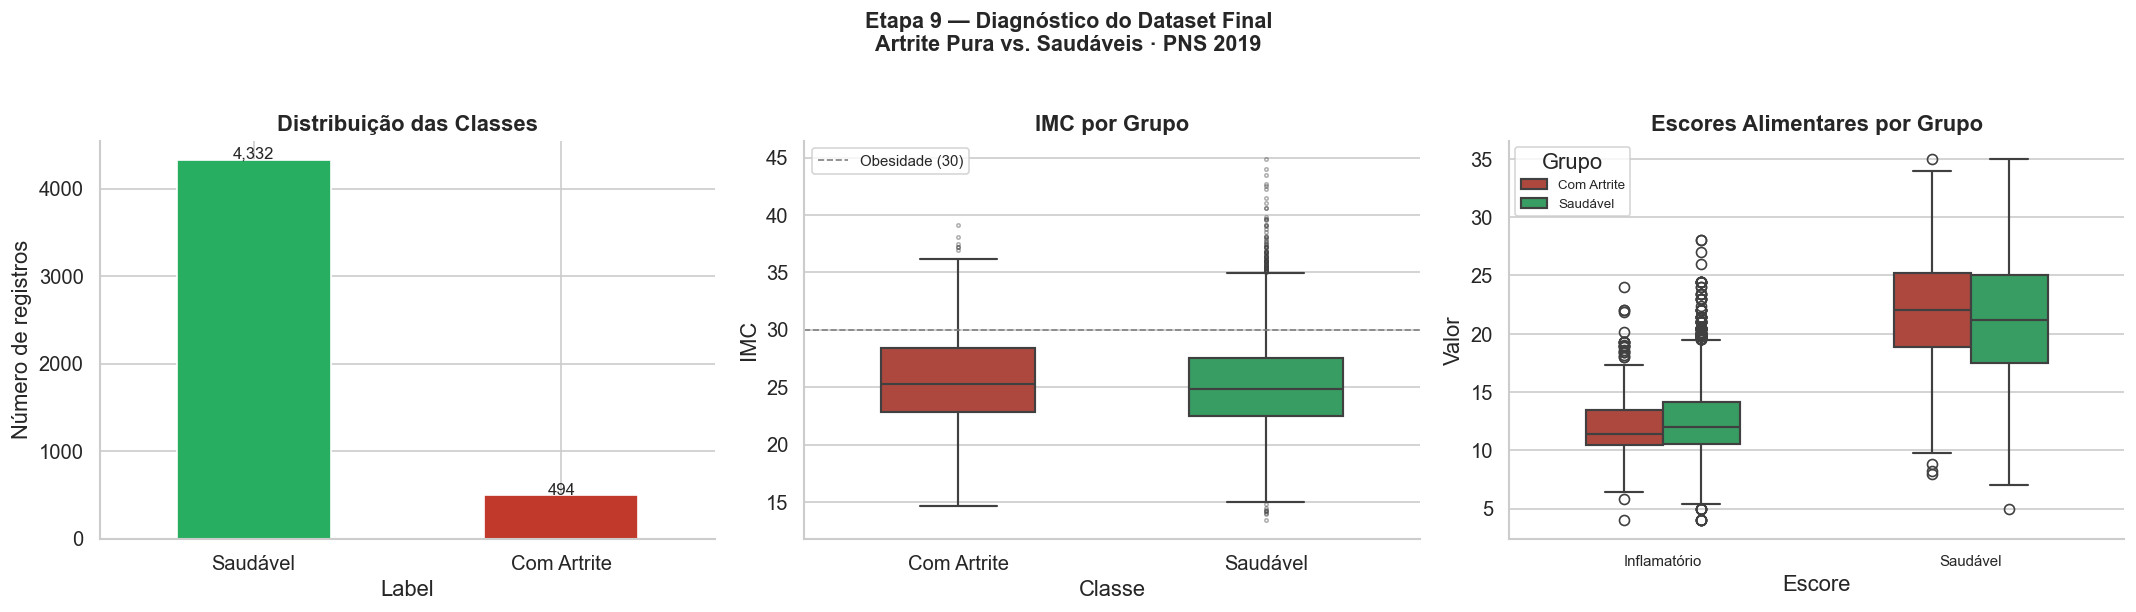

In [15]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 15 — Visualizações do Dataset Final
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1: classes
contagem = y.value_counts().rename(index={0:'Saudável', 1:'Com Artrite'})
contagem.plot(kind='bar', ax=axes[0], color=[COR_SAUDAVEL, COR_ARTRITE],
              edgecolor='white', rot=0)
axes[0].set_title('Distribuição das Classes', fontweight='bold')
axes[0].set_ylabel('Número de registros')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v+10, f'{v:,}', ha='center', fontsize=10)

# Painel 2: IMC
if 'IMC' in df_final.columns:
    sns.boxplot(data=df_final, x='Classe', y='IMC', ax=axes[1],
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                order=['Com Artrite','Saudável'], width=0.5, linewidth=1.3,
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[1].set_title('IMC por Grupo', fontweight='bold')
    axes[1].axhline(30, color='gray', linestyle='--', linewidth=1, label='Obesidade (30)')
    axes[1].legend(fontsize=9)

# Painel 3: Escores
if 'Escore_Inflamatorio' in df_final.columns and 'Escore_Saudavel' in df_final.columns:
    df_esc = pd.melt(df_final[['Classe','Escore_Inflamatorio','Escore_Saudavel']],
                     id_vars='Classe', var_name='Escore', value_name='Valor')
    sns.boxplot(data=df_esc, x='Escore', y='Valor', hue='Classe', ax=axes[2],
                palette={'Com Artrite': COR_ARTRITE, 'Saudável': COR_SAUDAVEL},
                width=0.5, linewidth=1.3)
    axes[2].set_title('Escores Alimentares por Grupo', fontweight='bold')
    axes[2].set_xticklabels(['Inflamatório', 'Saudável'], fontsize=9)
    axes[2].legend(title='Grupo', fontsize=8)

fig.suptitle('Etapa 9 — Diagnóstico do Dataset Final\nArtrite Pura vs. Saudáveis · PNS 2019',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
salvar_fig('etapa9_diagnostico_dataset_final.png')
plt.show()


In [16]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 16 — Exportação e Relatório de Rastreabilidade
# ══════════════════════════════════════════════════════════════════════

df_export = X.copy()
df_export['Label'] = y.values
caminho_dataset = DIR_RESULTADOS + 'dataset_preprocessado.csv'
df_export.to_csv(caminho_dataset, index=False, encoding='utf-8-sig')
print(f'  ✅ Dataset → {caminho_dataset}  ({df_export.shape[0]:,} × {df_export.shape[1]})')

relatorio = {
    'projeto'    : 'Artrite e Reumatismo em Idosos Brasileiros — PNS 2019',
    'pesquisador': 'Pedro Dias Soares',
    'orientador' : 'Prof. Dr. Luis Enrique Zárate — PUC Minas',
    'notebook'   : '03_preprocessamento',
    'versao'     : 'v3 — skip patterns resolvidos',
    'parametros' : {
        'LIMITE_MISSING_pct'  : LIMITE_MISSING * 100,
        'LIMITE_IQR_MULT'     : LIMITE_IQR_MULT,
        'RANDOM_STATE'        : RANDOM_STATE,
        'metodo_imputacao_num': 'Média por classe (missing real)',
        'metodo_imputacao_cat': 'Moda por classe (missing real)',
    },
    'rastreabilidade': {
        'etapa_1_carga': {
            'registros_brutos'    : int(df_raw.shape[0]),
            'registros_validos'   : int(df_raw.shape[0]),
            'variaveis_carregadas': int(df_raw.shape[1])
        },
        'etapa_2_5_skip_patterns': {
            'total_preenchidos': int(tab_skip['n_preenchidos'].sum()),
            'detalhes': tab_skip.to_dict('records')
        },
        'etapa_3_missing': {
            'vars_excluidas_>75pct': vars_excluir,
            'n_excluidas'          : len(vars_excluir)
        },
        'etapa_4_outliers': {
            'total_outliers_substituidos': int(tab_outliers['n_outliers'].sum()),
            'parametro_usado'            : f'{LIMITE_IQR_MULT}xIQR por classe',
            'detalhes': tab_outliers[tab_outliers['n_outliers'] > 0][
                ['Variável','n_outliers','% outliers']].to_dict('records')
        },
        'etapa_5_imputacao': {
            'total_imputados'  : int(tab_imp['n_imputados'].sum()),
            'nan_residual_em_X': int(nan_restante),
            'detalhes': tab_imp[tab_imp['n_imputados'] > 0][
                ['Variável','Tipo','Método','n_imputados']].to_dict('records')
        },
        'etapa_6_fusao': {
            'features_criadas' : ['IMC','Escore_Inflamatorio','Escore_Saudavel','Razao_Inf_Saud'],
            'formula_imc'      : 'Peso(kg) / (Altura(m))²',
            'componentes_infla': vars_infla,
            'componentes_saud' : vars_saud
        },
        'etapa_7_categorizacao': {
            'features_cat_criadas': novas_cat,
            'limitacao': 'Renda_cat/Saude_cat não criadas (VDF004/N001=100% missing)'
        },
        'etapa_8_encoding': {
            'label_encoding': cols_label,
            'ohe_encoding'  : cols_ohe,
            'excluidas_ohe' : ['Q092 (constante na amostra artrite pura)'],
            'removidas_df'  : ['Q092 (BUG-01 corrigido)']
        },
        'etapa_9_dataset_final': {
            'n_registros'            : int(X.shape[0]),
            'n_features'             : int(X.shape[1]),
            'distribuicao_label'     : {str(k): int(v) for k,v in y.value_counts().items()},
            'razao_desbalanceamento' : round(razao, 2),
            'arquivo'                : caminho_dataset
        }
    }
}

caminho_relatorio = DIR_RESULTADOS + 'relatorio_preprocessamento.json'
with open(caminho_relatorio, 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)
print(f'  ✅ Relatório → {caminho_relatorio}')


  ✅ Dataset → ../data/results/preprocessing/dataset_preprocessado.csv  (4,826 × 50)
  ✅ Relatório → ../data/results/preprocessing/relatorio_preprocessamento.json


In [17]:

# ══════════════════════════════════════════════════════════════════════
# CÉLULA 17 — Sumário Final
# ══════════════════════════════════════════════════════════════════════

print('=' * 80)
print('  ✅  NOTEBOOK 03 v3 — PRÉ-PROCESSAMENTO CONCLUÍDO')
print('=' * 80)

print('\n  CORREÇÕES ACUMULADAS:')
print('  [BUG-01] Q092 removida do DataFrame após OHE')
print('  [BUG-02] nan_restante (era missing_restante → NameError)')
print('  [INC-01] Limiar 75% alinhado em código + plano + JSON')
print(f'  [INC-02] LIMITE_IQR_MULT={LIMITE_IQR_MULT}×IQR (era LIMITE_IQR_DP — nome incorreto)')
print('  [SUG-01] Diagnóstico OHE: alerta para variáveis sem colunas')
print('  [SUG-02] Nota MCAR/MAR na auditoria de missing')
print('  [v3-SKIP] ⭐ Etapa 2.5: resolução de 7 skip patterns do questionário PNS')

print('\n  RESUMO DAS ETAPAS:')
print(f'  [1] Carregamento        : {df_raw.shape[0]:,} registros × {df_raw.shape[1]} colunas')
print(f'  [2.5] Skip Patterns     : {tab_skip["n_preenchidos"].sum():,} NaNs estruturais preenchidos')
for _, row in tab_skip.iterrows():
    print(f'       {row["Variável"]:8s}: {row["n_preenchidos"]:,} ({row["Condição"][:45]})')
print(f'  [3] Auditoria missing   : {len(vars_excluir)} variáveis excluídas (>{int(LIMITE_MISSING*100)}% missing real)')
print(f'  [4] Outliers            : {int(tab_outliers["n_outliers"].sum()):,} → NaN ({LIMITE_IQR_MULT}×IQR/classe)')
print(f'  [5] Imputação           : {int(tab_imp["n_imputados"].sum()):,} valores imputados (missing real)')
print(f'  [6] Fusão               : IMC, Escore_Infla, Escore_Saud, Razao')
print(f'  [7] Categorização       : {len(novas_cat)} features _cat')
print(f'  [8] Encoding            : Label Enc. + OHE (drop_first=True)')
print(f'  [9] Dataset final       : {X.shape[0]:,} × {X.shape[1]} features + Label')

print('\n  DISTRIBUIÇÃO DO ALVO:')
for label, nome in [(0,'Saudável (0)'), (1,'Com Artrite (1)')]:
    n   = int((y == label).sum())
    pct = 100 * n / len(y)
    print(f'    {nome:18s}: {n:,} ({pct:.1f}%)')

print('\n  IMPACTO DOS SKIP PATTERNS (comparação metodológica):')
print('  Variable  | Antes (com NaN estrut.) | Depois (valores corretos)')
print('  --------- | ----------------------- | -------------------------')
print('  J012      | NaN imputado pela média  | 0 para quem não consultou no ano')
print('  P035      | NaN imputado pela média  | 0 para quem não praticou exercício')
print('  P02801    | NaN imputado pela média  | 0 para quem nunca/raramente bebe')
print('  P029      | NaN imputado pela média  | 0 para quem nunca bebe')
print('  P03201    | NaN imputado pela moda   | "Não" para quem nunca bebe')

print('\n' + '=' * 80)
print('  Próximo → Notebook 04: RUS + Algoritmos ML')
print('  Análise de sensibilidade recomendada: modelo com/sem P035, P02001, P029')
print('=' * 80)


  ✅  NOTEBOOK 03 v3 — PRÉ-PROCESSAMENTO CONCLUÍDO

  CORREÇÕES ACUMULADAS:
  [BUG-01] Q092 removida do DataFrame após OHE
  [BUG-02] nan_restante (era missing_restante → NameError)
  [INC-01] Limiar 75% alinhado em código + plano + JSON
  [INC-02] LIMITE_IQR_MULT=3.0×IQR (era LIMITE_IQR_DP — nome incorreto)
  [SUG-01] Diagnóstico OHE: alerta para variáveis sem colunas
  [SUG-02] Nota MCAR/MAR na auditoria de missing
  [v3-SKIP] ⭐ Etapa 2.5: resolução de 7 skip patterns do questionário PNS

  RESUMO DAS ETAPAS:
  [1] Carregamento        : 4,826 registros × 53 colunas
  [2.5] Skip Patterns     : 1,344 NaNs estruturais preenchidos
       P035    : 0 (P034=2 (Não))
       P02801  : 0 (P027∈{1,2} (não bebe semanalmente))
       P029    : 0 (P027=1 (nunca bebe))
       P03201  : 0 (P027=1 (nunca bebe))
       J012    : 1,344 (J01101≠1 (não consultou no último ano))
       G060    : 0 (G059=2 (não usa aparelho))
       G062    : 0 (G059=2 (não usa aparelho))
  [3] Auditoria missing   : 13 var